In [1]:
import pandas as pd

df = pd.read_csv('../../multi_task_learning/dataset/hardness_yang2022+dft_full.csv', index_col=0)
display(df.head())  # show a preview of the data
print(df.shape)

,Composition,HV,atomicNumber,ISIS,USFE,PP_radius_s,PP_radius_p,EleNeg_Miedema,EleDensity_Miedema,V0_Miedema,...,GvsqY,KGS,SQGusfp,SQusf,normUSFE,density0K [g/cm^3],price [$/kg],price [$/cm^3],deltaS,FT
0,Co22.2Cr22.2Fe22.2Ni22.2Mo11.1,220.0,28.000000,9.425111,0.768667,1.002222,1.244444,4.934444,5.383333,7.182222,...,5.780889,17.677156,12.700811,0.821678,4.370444,8.556946,17.016445,0.153786,-1.581094,13.919083
1,Al10Co20Cr20Fe20Ni20Mo10,440.0,26.500000,8.748800,0.707600,0.979000,1.210500,4.861000,5.115000,7.464000,...,5.494000,16.446070,11.768150,0.779280,4.348500,7.971410,15.493800,0.138891,-1.748067,12.905781
2,Al20Co10Cr20Fe20Ni20Mo10,801.0,25.100000,8.519800,0.700400,0.964000,1.191000,4.771000,4.849000,7.794000,...,5.154200,15.214490,11.288260,0.771130,4.608300,7.344184,12.392800,0.109941,-1.748067,12.254057
3,Al20Co20Cr20Fe10Ni20Mo10,755.0,25.200000,8.259500,0.642700,0.961000,1.185000,4.788000,4.830000,7.755000,...,5.231600,15.255470,10.726230,0.729230,4.355800,7.425306,15.630400,0.139029,-1.748067,11.894291
4,Al19.6Co19.6Cr19.6Fe11.8Ni19.6Mo9.8,754.0,25.215999,8.245410,0.645986,0.960780,1.184500,4.790840,4.844400,7.741700,...,5.237688,15.295806,10.787573,0.732609,4.350244,7.440052,15.326272,0.136317,-1.757446,11.933126


(370, 84)


In [2]:
import re

def parse_alloy_composition(composition):
    # Regular expression to match elements and their amounts
    pattern = re.compile(r'([A-Z][a-z]*)(\d*\.?\d*)')
    matches = pattern.findall(composition)
    
    # Create a dictionary to store elements and their amounts
    elements = {}
    for element, amount in matches:
        if amount == '':
            amount = 1.0  # Default amount is 1 if not specified
        else:
            amount = float(amount)
        elements[element] = amount
    
    return elements


ele_dict = [parse_alloy_composition(it) for it in df['Composition']]
print(len(ele_dict))

370


In [3]:
ele_occurence = {}
for c in ele_dict:
    for k in c.keys():
        if k not in ele_occurence:
            ele_occurence[k] = 0
        ele_occurence[k] += 1
print(ele_occurence)

{'Co': 297, 'Cr': 345, 'Fe': 361, 'Ni': 338, 'Mo': 30, 'Al': 299, 'Mn': 37, 'V': 34, 'Cu': 198, 'Ti': 55}


In [4]:
import numpy as np

ele_lookup = {k: i for i, k in enumerate(sorted(ele_occurence.keys()))}
ele_arr = np.zeros([len(df), len(ele_occurence)], dtype=float)
for idx, comp in enumerate(ele_dict):
    for ele, frac in comp.items():
        ele_arr[idx, ele_lookup[ele]] = frac
ele_arr /= ele_arr.sum(axis=1).reshape(-1, 1)
print(np.percentile(np.sum(ele_arr, axis=1), [0, 100]))
df_comp = pd.DataFrame(ele_arr, columns=ele_lookup.keys())

[1. 1.]


In [376]:
df.iloc[:, 1:].corr()['FT']**2

HV                    0.164436
atomicNumber          0.383115
ISIS                  0.866746
USFE                  0.813116
PP_radius_s           0.353079
                        ...   
density0K [g/cm^3]    0.404201
price [$/kg]          0.003099
price [$/cm^3]        0.007593
deltaS                0.021076
FT                    1.000000
Name: FT, Length: 83, dtype: float64

In [153]:
main_task = ['HV']
aux_tasks = ['V0_Miedema', 'DFTv0', 'Nval']
tasks = main_task + aux_tasks

In [377]:
main_task = ['FT']
aux_tasks = ['SQGusfp', 'G_wiki', 'Y_wiki']
tasks = main_task + aux_tasks

In [372]:
import numpy as np

missing = df.copy(deep=True)

f_missing = 0.33
rng = np.random.default_rng(0)
mode = 'extrapolate'

miss_idx = []
for i, col in enumerate(main_task):
    print(col)
    if mode == 'extrapolate':
        pct_missing = 100 * f_missing
        lo, hi = np.percentile(missing[col], [pct_missing/2, 100-pct_missing/2])
        rand_idx = np.argwhere((missing[col] < lo) | (missing[col] > hi)).flatten()
        print(lo, hi)
    elif mode == 'interpolate':
        pct_missing = 100 * f_missing
        lo, hi = np.percentile(missing[col], 0.5*np.array([100-pct_missing, 100+pct_missing]))
        rand_idx = np.argwhere((missing[col] > lo) & (missing[col] < hi)).flatten()
    elif mode == 'random':
        n_missing = int(f_missing * df.shape[0])
        rand_idx = rng.choice(np.arange(missing.shape[0]), n_missing, replace=False)
    else:
        raise ValueError('Mode must be one of {extrapolate, interpolate, random}')
    missing.loc[rand_idx, col] = np.nan
    miss_idx.append(rand_idx)

display(missing.loc[:, tasks])
print(np.sum(~np.isnan(missing.loc[:, tasks]), axis=0))

HV
183.0 729.69


,HV,V0_Miedema,DFTv0,Nval
0,220.0,7.182222,11.718222,8.000000
1,440.0,7.464000,12.204200,7.500000
2,NaN,7.794000,12.771900,6.900000
3,NaN,7.755000,12.726200,7.000000
4,NaN,7.741700,12.698836,7.020000
...,...,...,...,...
365,NaN,8.228900,13.487230,5.880000
366,392.0,8.075385,13.277752,7.317317
367,452.0,8.158327,13.419976,7.131262
368,350.2,7.524000,12.266400,7.200000


HV            250
V0_Miedema    370
DFTv0         370
Nval          370
dtype: int64


In [373]:
import torch
from sklearn import model_selection, preprocessing

x = df_comp
y = missing.loc[:, tasks]

# x_train, x_vt, y_train, y_vt = model_selection.train_test_split(x, y, train_size=0.6, random_state=0)
# x_valid, x_test, y_valid, y_test = model_selection.train_test_split(x_vt, y_vt, train_size=0.5, random_state=0)

train_idx = np.isfinite(missing.loc[:, main_task].values)

x_train, x_valid, y_train, y_valid = model_selection.train_test_split(x.loc[train_idx], y.loc[train_idx], train_size=0.90, random_state=0)

# use the whole missing set...
# test_idx = np.argwhere(np.isnan(missing.loc[:, main_task])).flatten()
# test_idx = np.isnan(missing.loc[:, main_task].values)
test_idx = np.logical_not(train_idx)
x_test = df_comp.loc[test_idx]
y_test = df.copy().loc[test_idx, tasks]

x_scaler = preprocessing.StandardScaler().fit(x_train.values)
y_scaler = preprocessing.StandardScaler().fit(y_train.values)

x_train = torch.tensor(x_scaler.transform(x_train.values)).float()
y_train = torch.tensor(y_scaler.transform(y_train.values)).float()

x_valid = torch.tensor(x_scaler.transform(x_valid.values)).float()
y_valid = torch.tensor(y_scaler.transform(y_valid.values)).float()

x_test = torch.tensor(x_scaler.transform(x_test.values)).float()
y_test = torch.tensor(y_scaler.transform(y_test.values)).float()

print(x_train.shape, x_valid.shape, x_test.shape)

torch.Size([225, 10]) torch.Size([25, 10]) torch.Size([120, 10])


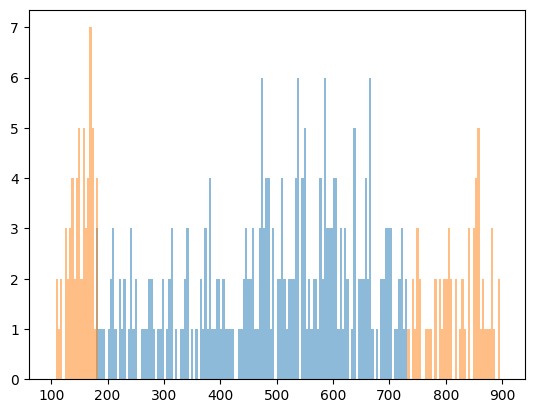

In [374]:
_ = plt.hist(df.loc[train_idx, main_task].values, bins=np.linspace(100, 900, 201), alpha=0.5)
_ = plt.hist(df.loc[test_idx, main_task].values, bins=np.linspace(100, 900, 201), alpha=0.5)

In [375]:
from matplotlib import pyplot as plt
from sklearn import ensemble, metrics


def plot_model_parity(model):

    model.eval()
    with torch.no_grad():
        out_train = model(x_train)
        out_valid = model(x_valid)
        out_test = model(x_test)
    
    fig, axes = plt.subplots(2, 2)
    axes = axes.flatten()
    for i in range(out_valid.shape[1]):
        min_max = [op(y_valid[:, i].numpy()) for op in (np.nanmin, np.nanmax)]
        axes[i].plot(min_max, min_max, 'k--', zorder=0)
        axes[i].scatter(out_train[:, i].numpy(), y_train[:, i].numpy(), s=2, alpha=0.33)
        axes[i].scatter(out_valid[:, i].numpy(), y_valid[:, i].numpy(), s=2, alpha=0.33)
        axes[i].scatter(out_test[:, i].numpy(), y_test[:, i].numpy(), s=2, alpha=0.33)
        test_finite = np.isfinite(y_test[:, i].numpy())
        r2 = metrics.r2_score(y_test[test_finite, i].numpy(), out_test[test_finite, i].numpy())
        resid = y_test[test_finite, i].numpy() - out_test[test_finite, i].numpy()
        mae = metrics.mean_absolute_error(y_test[test_finite, i].numpy(), out_test[test_finite, i].numpy())
        print('my R2', 1 - np.var(resid) / np.var(y_test[test_finite, i].numpy()))
        # axes[i].text(0.05, 0.95, f'$R^2 = {r2:.3f}$', transform=axes[i].transAxes, ha='left', va='top')
        axes[i].text(0.05, 0.95, f'MAE = {mae:.3f}', transform=axes[i].transAxes, ha='left', va='top')
        axes[i].set_xlim(-3, 3)
        axes[i].set_ylim(-3, 3)

        
def plot_ref_parity():
    
    fig, axes = plt.subplots(2, 2)
    axes = axes.flatten()
    for i in range(y_valid.shape[1]):
        
        rf = ensemble.RandomForestRegressor(random_state=0)
    
        is_finite = np.isfinite(y_train[:, i].numpy())
        # print(np.sum(is_finite))
        _ = rf.fit(x_train[is_finite].numpy(), y_train[is_finite][:, i].numpy())
        
        out_train = rf.predict(x_train.numpy())
        out_valid = rf.predict(x_valid.numpy())
        out_test = rf.predict(x_test.numpy())

        test_finite = np.isfinite(y_test[:, i].numpy())
        # print(np.sum(test_finite))
        r2_test = metrics.r2_score(y_test[test_finite, i].numpy(), out_test[test_finite])
        
        resid = y_test[test_finite, i].numpy() - out_test[test_finite]
        # print('my R2', 1 - np.var(resid) / np.var(y_test[test_finite, i].numpy()))
        
        mae = metrics.mean_absolute_error(y_test[test_finite, i].numpy(), out_test[test_finite])
        # print(mae)
        mse = metrics.mean_squared_error(y_test[test_finite, i].numpy(), out_test[test_finite])
        # print(np.sqrt(mse))

        min_max = [op(y_valid[:, i].numpy()) for op in (np.nanmin, np.nanmax)]
        axes[i].plot(min_max, min_max, 'k--', zorder=0)
        
        axes[i].scatter(out_train, y_train[:, i].numpy(), s=2, alpha=0.33)
        axes[i].scatter(out_valid, y_valid[:, i].numpy(), s=2, alpha=0.33)
        axes[i].scatter(out_test, y_test[:, i].numpy(), s=2, alpha=0.33)

        # axes[i].text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=axes[i].transAxes, ha='left', va='top')
        axes[i].text(0.05, 0.95, f'MAE = {mae:.3f}', transform=axes[i].transAxes, ha='left', va='top')
        axes[i].set_xlim(-3, 3)
        axes[i].set_ylim(-3, 3)        

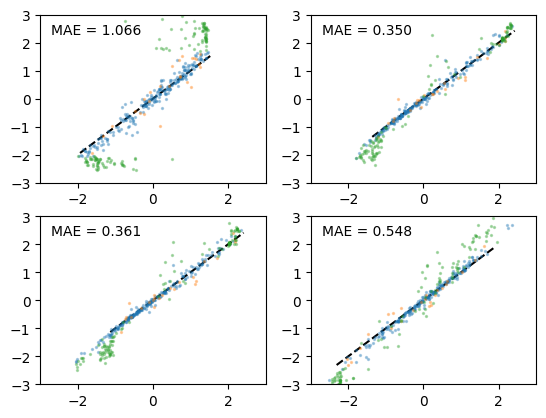

In [376]:
plot_ref_parity()

In [386]:
from torch import nn, optim
import sparsenn
from sparsenn import pareto
from copy import deepcopy

input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = 1

st_model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim, activation=nn.ELU())
criterion = sparsenn.MultiTaskMSELoss()
optimizer = optim.Adam(st_model.parameters(), lr=1e-3)

explored_values = []
frontier = []

max_epochs = int(1e5)

best_model = deepcopy(st_model)

main_task_id = [0]

lmbda_reg = 0
reg_prec = 3
nwrite = 1000
patience_interval = nwrite * 5
last_best = 0
best_valid = np.inf
last_best_valid = 0
st_model.train()
for epoch in range(max_epochs):
    optimizer.zero_grad()
    outputs = st_model(x_train)
    loss = criterion(outputs, y_train[:, main_task_id])
    reg_loss = st_model.regularization_loss()
    total_loss = loss + lmbda_reg * reg_loss
    total_loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        outputs = st_model(x_valid)
        valid_loss = criterion(outputs[:, main_task_id], y_valid[:, main_task_id])
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            last_best_valid = epoch
            best_model = deepcopy(st_model)

    if reg_loss.item() < 1:
        break

    if (epoch+1) % nwrite == 0:
        with torch.no_grad():
            outputs = st_model(x_test)
            test_loss = criterion(outputs, y_test[:, main_task_id])
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
    
    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break
    
    if epoch - last_best_valid > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

Epoch 1000, MSE: 0.3102, L0R: 860.64, ValMSE: 0.2262, TestMSE: 0.5925
Epoch 2000, MSE: 0.2505, L0R: 867.70, ValMSE: 0.4258, TestMSE: 0.7218
Epoch 3000, MSE: 0.2789, L0R: 873.88, ValMSE: 0.1819, TestMSE: 1.1516
Epoch 4000, MSE: 0.2709, L0R: 879.38, ValMSE: 0.2671, TestMSE: 1.1929
Epoch 5000, MSE: 0.2042, L0R: 884.83, ValMSE: 0.1323, TestMSE: 0.7848
Epoch 6000, MSE: 0.1673, L0R: 889.90, ValMSE: 0.1920, TestMSE: 1.3587
Epoch 7000, MSE: 0.1768, L0R: 894.33, ValMSE: 0.2315, TestMSE: 0.5762
Epoch 8000, MSE: 0.1479, L0R: 898.48, ValMSE: 0.1816, TestMSE: 0.7452
Epoch 9000, MSE: 0.1694, L0R: 902.37, ValMSE: 0.1488, TestMSE: 0.5875
Epoch 10000, MSE: 0.1128, L0R: 906.15, ValMSE: 0.1409, TestMSE: 1.4620
Epoch 11000, MSE: 0.1469, L0R: 909.85, ValMSE: 0.1913, TestMSE: 0.9114
Epoch 12000, MSE: 0.1676, L0R: 913.16, ValMSE: 0.1068, TestMSE: 0.5157
Epoch 13000, MSE: 0.1217, L0R: 916.32, ValMSE: 0.1679, TestMSE: 0.7777
Epoch 14000, MSE: 0.1011, L0R: 919.32, ValMSE: 0.2431, TestMSE: 1.4844
Epoch 15000, MS

In [387]:
st_model = deepcopy(best_model)

my R2 0.9589698240160942


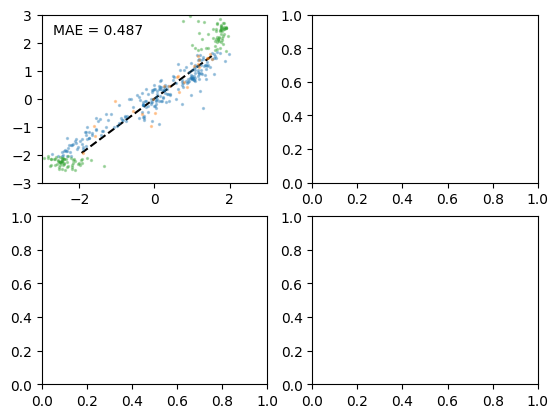

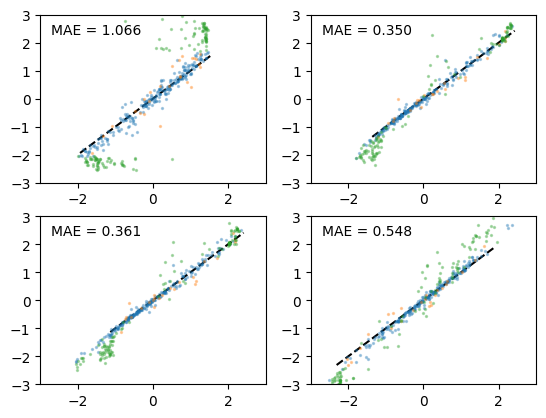

In [388]:
_ = plot_model_parity(st_model)
_ = plot_ref_parity()

In [306]:
from torch import nn, optim
import sparsenn
from sparsenn import pareto
from copy import deepcopy

input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = y_train.shape[1]

model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim, activation=nn.ELU())
criterion = sparsenn.MultiTaskMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

explored_values = []
frontier = []

max_epochs = int(1e5)

best_model = deepcopy(model)

main_task_id = 0

lmbda_reg = 1e-5
reg_prec = 3
nwrite = 1000
patience_interval = nwrite * 5
last_best = 0
last_valid_best = 0
best_valid = np.inf
model.train()
for epoch in range(max_epochs):
    optimizer.zero_grad()
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    reg_loss = model.regularization_loss()
    total_loss = loss + lmbda_reg * reg_loss
    total_loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        outputs = model(x_valid)
        valid_loss = criterion(outputs[:, main_task_id], y_valid[:, main_task_id])
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            last_valid_best = epoch
            best_model = deepcopy(model)

    if reg_loss.item() < 1:
        break

    if (epoch+1) % nwrite == 0:
        with torch.no_grad():
            outputs = model(x_test)
            test_loss = criterion(outputs, y_test)
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
    
    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break
        
    if epoch - last_valid_best > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

Epoch 1000, MSE: 0.0682, L0R: 918.83, ValMSE: 0.0978, TestMSE: 0.0495
Epoch 2000, MSE: 0.0621, L0R: 920.80, ValMSE: 0.0937, TestMSE: 0.0452
Epoch 3000, MSE: 0.0911, L0R: 922.40, ValMSE: 0.0583, TestMSE: 0.0610
Epoch 4000, MSE: 0.0409, L0R: 924.22, ValMSE: 0.1075, TestMSE: 0.0564
Epoch 5000, MSE: 0.0296, L0R: 925.87, ValMSE: 0.0601, TestMSE: 0.0757
Epoch 6000, MSE: 0.0641, L0R: 926.86, ValMSE: 0.0548, TestMSE: 0.0562
Epoch 7000, MSE: 0.0419, L0R: 927.36, ValMSE: 0.0428, TestMSE: 0.0447
Epoch 8000, MSE: 0.0413, L0R: 926.58, ValMSE: 0.0409, TestMSE: 0.0277
Epoch 9000, MSE: 0.0293, L0R: 925.21, ValMSE: 0.0426, TestMSE: 0.0753
Epoch 10000, MSE: 0.0255, L0R: 922.67, ValMSE: 0.0511, TestMSE: 0.0726
Epoch 11000, MSE: 0.0506, L0R: 918.53, ValMSE: 0.1689, TestMSE: 0.0836
Epoch 12000, MSE: 0.0115, L0R: 913.03, ValMSE: 0.0327, TestMSE: 0.0815
Epoch 13000, MSE: 0.0209, L0R: 905.31, ValMSE: 0.0445, TestMSE: 0.0528
Epoch 14000, MSE: 0.0161, L0R: 896.00, ValMSE: 0.0295, TestMSE: 0.0669
Epoch 15000, MS

my R2 -2.0884573459625244
my R2 0.9213294982910156
my R2 0.9596245139837265
my R2 0.942350260913372
my R2 -3.25567626953125


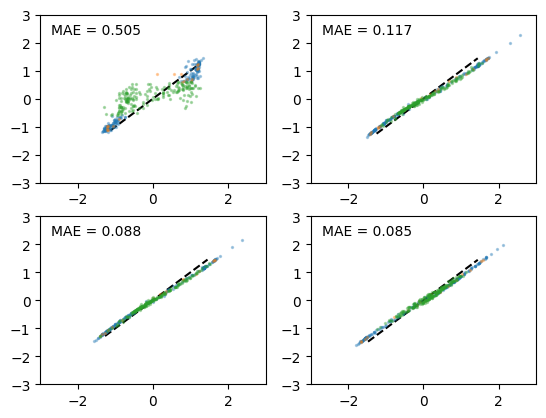

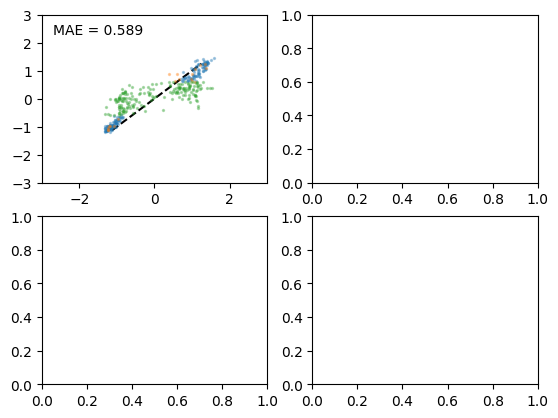

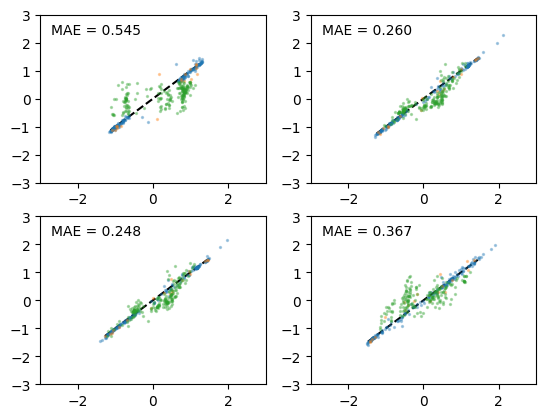

In [307]:
_ = plot_model_parity(best_model)
_ = plot_model_parity(st_model)
_ = plot_ref_parity()

In [310]:
import torch
import torch.optim as optim

class PCGrad:
    def __init__(self, model, num_tasks, optimizer, criterion, lambda_reg=0.):
        self.model = model
        self.num_tasks = num_tasks
        self.base_optimizer = optimizer
        self.criterion = criterion
        self.lambda_reg = lambda_reg
    
    def compute_losses(self, output, target):
        if self.lambda_reg > 0:
            reg_loss = self.model.regularization_loss()
        else:
            reg_loss = 0.
        losses = []
        for i in range(self.num_tasks):
            task_output = output[:, i].unsqueeze(1)
            task_target = target[:, i].unsqueeze(1)
            task_loss = self.criterion(task_output, task_target)
            total_loss = task_loss + self.lambda_reg * reg_loss / self.num_tasks
            losses.append(total_loss)
        return losses
    
    def compute_gradients(self, losses):
        grads = []
        for loss in losses:
            self.base_optimizer.zero_grad()
            loss.backward(retain_graph=True)
            grad = []
            for param in self.model.parameters():
                if param.grad is not None:
                    grad.append(param.grad.view(-1))
            grads.append(torch.cat(grad))
        return torch.stack(grads)
    
    def project_gradients(self, grads):
        proj_grads = grads.clone()
        for i in range(self.num_tasks):
            for j in range(self.num_tasks):
                if i != j:
                    inner_product = torch.dot(proj_grads[i], grads[j])
                    proj_direction = inner_product / torch.dot(grads[j], grads[j])
                    proj_grads[i] -= torch.clamp(proj_direction, min=0) * grads[j]
        return proj_grads.mean(dim=0)
    
    def apply_gradients(self, grad):
        idx = 0
        for param in self.model.parameters():
            if param.grad is not None:
                size = param.grad.numel()
                param.grad.data = grad[idx:idx+size].view_as(param.data)
                idx += size
    
    def train_step(self, inputs, targets):
        self.model.train()
        outputs = self.model(inputs)
        losses = self.compute_losses(outputs, targets)
        grads = self.compute_gradients(losses)
        pcgrad = self.project_gradients(grads)
        self.apply_gradients(pcgrad)
        self.base_optimizer.step()
        return [loss.item() for loss in losses]
    
    
input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = y_train.shape[1]
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim, activation=nn.ELU())
optimizer = optim.Adam(model.parameters(), lr=1e-2)
pcgrad_mtl = PCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5)

best = (0, np.inf, deepcopy(model))

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 5 * n_write
for epoch in range(num_epochs):
    losses = pcgrad_mtl.train_step(x_train, y_train)

    if (epoch+1) % n_write == 0:
        m = pcgrad_mtl.model
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train), y_train)
            valid_loss = criterion(m(x_valid), y_valid)
            test_loss = criterion(m(x_test), y_test)
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        if valid_loss < best[1]:
            best = (epoch, valid_loss, deepcopy(m))
        if epoch - best[0] > patience_interval:
            print('Patience expired...')
            break
        m.train()
# retain the best validation loss
model = deepcopy(best[2])    

Epoch 100, MSE: 0.4608, L0R: 913.29, ValMSE: 0.4441, TestMSE: 0.1299
Epoch 200, MSE: 0.0509, L0R: 917.22, ValMSE: 0.0478, TestMSE: 0.0521
Epoch 300, MSE: 0.0374, L0R: 918.30, ValMSE: 0.0378, TestMSE: 0.0487
Epoch 400, MSE: 0.0324, L0R: 918.56, ValMSE: 0.0315, TestMSE: 0.0398
Epoch 500, MSE: 0.0372, L0R: 919.15, ValMSE: 0.0330, TestMSE: 0.0479
Epoch 600, MSE: 0.0300, L0R: 919.04, ValMSE: 0.0270, TestMSE: 0.0419
Epoch 700, MSE: 0.0287, L0R: 919.35, ValMSE: 0.0263, TestMSE: 0.0389
Epoch 800, MSE: 0.0299, L0R: 919.90, ValMSE: 0.0265, TestMSE: 0.0418
Epoch 900, MSE: 0.0293, L0R: 920.25, ValMSE: 0.0261, TestMSE: 0.0420
Epoch 1000, MSE: 0.0278, L0R: 920.51, ValMSE: 0.0258, TestMSE: 0.0411
Epoch 1100, MSE: 0.0311, L0R: 920.99, ValMSE: 0.0261, TestMSE: 0.0432
Epoch 1200, MSE: 0.0284, L0R: 921.24, ValMSE: 0.0253, TestMSE: 0.0414
Epoch 1300, MSE: 0.0266, L0R: 921.49, ValMSE: 0.0227, TestMSE: 0.0407
Epoch 1400, MSE: 0.0337, L0R: 922.15, ValMSE: 0.0282, TestMSE: 0.0481
Epoch 1500, MSE: 0.0283, L0R:

my R2 -2.0884573459625244
my R2 0.9213294982910156
my R2 0.9596245139837265
my R2 0.942350260913372
my R2 -3.25567626953125


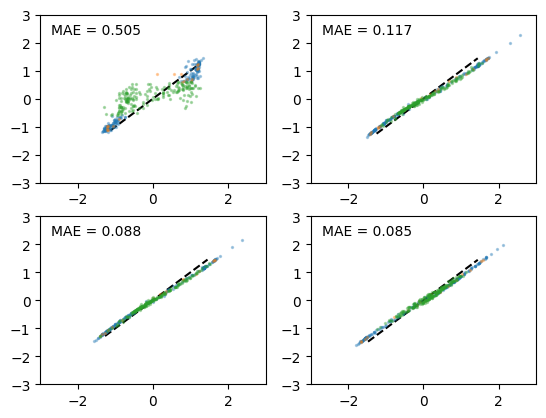

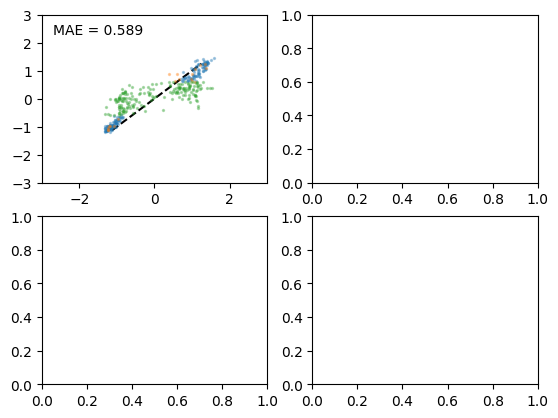

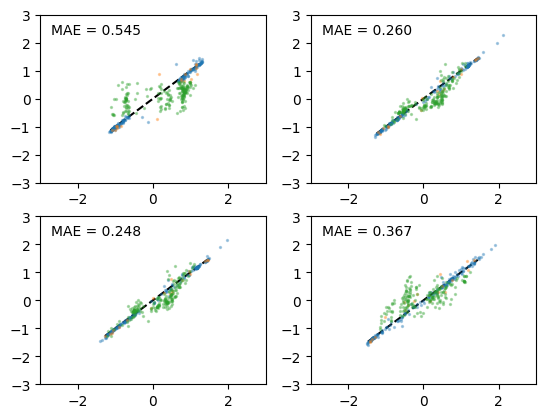

In [311]:
_ = plot_model_parity(best_model)
_ = plot_model_parity(st_model)
_ = plot_ref_parity()

In [402]:
input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = y_train.shape[1]
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim, activation=nn.ELU())
optimizer = optim.Adam(model.parameters(), lr=1e-3)
pcgrad_mtl = PCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5)

explored_values = []
frontier = []

best = (0, np.inf, deepcopy(model))

last_best = 0
last_valid_best = 0
best_valid = np.inf

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 5 * n_write
for epoch in range(num_epochs):
    losses = pcgrad_mtl.train_step(x_train, y_train)

    m = pcgrad_mtl.model
    with torch.no_grad():
        m.eval()
        reg_loss = m.regularization_loss()
        outputs = m(x_valid)
        valid_loss = criterion(outputs, y_valid)
        m.train()
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(m)
            last_valid_best = epoch

    if reg_loss.item() < 1:
        break

    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

    if epoch - last_valid_best > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

    if (epoch+1) % n_write == 0:
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train), y_train)
            valid_loss = criterion(m(x_valid), y_valid)
            test_loss = criterion(m(x_test), y_test)
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        m.train()

Epoch 100, MSE: 0.6718, L0R: 913.16, ValMSE: 0.6767, TestMSE: 2.6392
Epoch 200, MSE: 0.1759, L0R: 919.12, ValMSE: 0.1060, TestMSE: 0.4639
Epoch 300, MSE: 0.1309, L0R: 920.70, ValMSE: 0.0738, TestMSE: 0.3300
Epoch 400, MSE: 0.1149, L0R: 921.17, ValMSE: 0.0617, TestMSE: 0.3126
Epoch 500, MSE: 0.1094, L0R: 921.80, ValMSE: 0.0601, TestMSE: 0.2793
Epoch 600, MSE: 0.1062, L0R: 922.30, ValMSE: 0.0606, TestMSE: 0.2857
Epoch 700, MSE: 0.1032, L0R: 922.82, ValMSE: 0.0602, TestMSE: 0.2762
Epoch 800, MSE: 0.1042, L0R: 923.43, ValMSE: 0.0553, TestMSE: 0.2262
Epoch 900, MSE: 0.1039, L0R: 924.07, ValMSE: 0.0596, TestMSE: 0.2152
Epoch 1000, MSE: 0.0997, L0R: 924.36, ValMSE: 0.0530, TestMSE: 0.2051
Epoch 1100, MSE: 0.0968, L0R: 924.95, ValMSE: 0.0516, TestMSE: 0.2044
Epoch 1200, MSE: 0.0969, L0R: 925.54, ValMSE: 0.0530, TestMSE: 0.2027
Epoch 1300, MSE: 0.0977, L0R: 926.17, ValMSE: 0.0582, TestMSE: 0.2006
Epoch 1400, MSE: 0.0927, L0R: 926.57, ValMSE: 0.0512, TestMSE: 0.1956
Epoch 1500, MSE: 0.0912, L0R:

my R2 0.8857540339231491
my R2 0.9963462832383811
my R2 0.9950877348892391
my R2 0.9948694612830877
my R2 0.9589698240160942


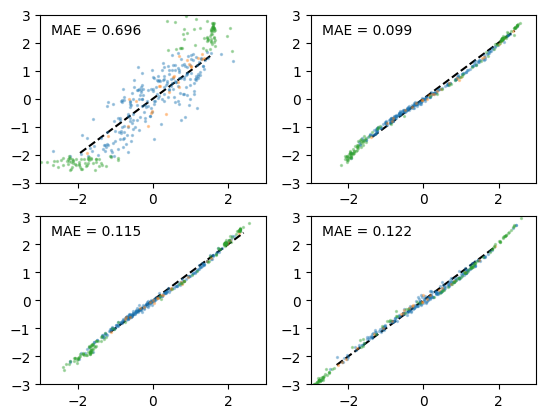

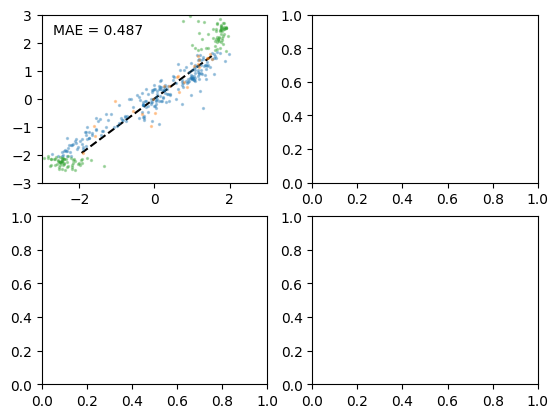

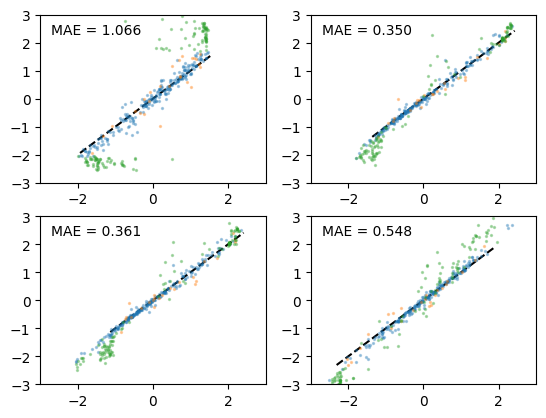

In [403]:
_ = plot_model_parity(best_model)
_ = plot_model_parity(st_model)
_ = plot_ref_parity()

In [316]:
import torch

class wPCGrad(PCGrad):
    def __init__(self, model, num_tasks, optimizer, criterion, lambda_reg=0., task_weights=None):
        super().__init__(model, num_tasks, optimizer, criterion, lambda_reg)
        if task_weights is None:
            self.task_weights = torch.ones(num_tasks) / num_tasks
        else:
            self.task_weights = task_weights 
    
    def update_task_weights(self, new_weights):
        self.task_weights = new_weights
    
    def project_gradients(self, grads):
        proj_grads = grads.clone()
        
        # Sample a task to remain unmodified based on task weights
        unmodified_task = torch.multinomial(self.task_weights, 1).item()
        
        for i in range(self.num_tasks):
            if i != unmodified_task:
                inner_product = torch.dot(proj_grads[i], grads[unmodified_task])
                if inner_product < 0:
                    proj_direction = inner_product / torch.dot(grads[unmodified_task], grads[unmodified_task])
                    proj_grads[i] -= proj_direction * grads[unmodified_task]
        
        return proj_grads.mean(dim=0)
    
    def train_step(self, inputs, targets):
        self.model.train()
        outputs = self.model(inputs)
        losses = self.compute_losses(outputs, targets)
        grads = self.compute_gradients(losses)
        wpcgrad = self.project_gradients(grads)
        self.apply_gradients(wpcgrad)
        self.base_optimizer.step()
        return [loss.item() for loss in losses]

In [317]:
input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = y_train.shape[1]
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim, activation=nn.ELU())
optimizer = optim.Adam(model.parameters(), lr=1e-2)
eps = 1e-3
tw = torch.tensor([1-len(aux_tasks)*eps] + [eps]*len(aux_tasks)).float()
pcgrad_mtl = wPCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5, task_weights=tw)

task_priority = [0]

explored_values = []
frontier = []

best = (0, np.inf, deepcopy(model))

last_best = 0
last_valid_best = 0
best_valid = np.inf

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 5 * n_write
for epoch in range(num_epochs):
    losses = pcgrad_mtl.train_step(x_train, y_train)

    m = pcgrad_mtl.model
    with torch.no_grad():
        m.eval()
        reg_loss = m.regularization_loss()
        outputs = m(x_valid)
        valid_loss = criterion(outputs[:, task_priority], y_valid[:, task_priority])
        m.train()
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(m)
            last_valid_best = epoch

    if reg_loss.item() < 1:
        break

    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

    if epoch - last_valid_best > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

    if (epoch+1) % n_write == 0:
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train)[:, task_priority], y_train[:, task_priority])
            valid_loss = criterion(m(x_valid)[:, task_priority], y_valid[:, task_priority])
            test_loss = criterion(m(x_test)[:, task_priority], y_test[:, task_priority])
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        m.train()

Epoch 100, MSE: 0.0996, L0R: 909.84, ValMSE: 0.0931, TestMSE: 0.1586
Epoch 200, MSE: 0.1242, L0R: 911.31, ValMSE: 0.0916, TestMSE: 0.2030
Epoch 300, MSE: 0.0828, L0R: 911.53, ValMSE: 0.0628, TestMSE: 0.1665
Epoch 400, MSE: 0.0828, L0R: 910.83, ValMSE: 0.0680, TestMSE: 0.1576
Epoch 500, MSE: 0.0749, L0R: 911.46, ValMSE: 0.0627, TestMSE: 0.1387
Epoch 600, MSE: 0.0896, L0R: 911.38, ValMSE: 0.0686, TestMSE: 0.1757
Epoch 700, MSE: 0.0721, L0R: 912.23, ValMSE: 0.0540, TestMSE: 0.1743
Epoch 800, MSE: 0.0679, L0R: 911.73, ValMSE: 0.0478, TestMSE: 0.1721
Epoch 900, MSE: 0.1081, L0R: 912.01, ValMSE: 0.0859, TestMSE: 0.2373
Epoch 1000, MSE: 0.0587, L0R: 912.02, ValMSE: 0.0400, TestMSE: 0.1685
Epoch 1100, MSE: 0.0767, L0R: 912.58, ValMSE: 0.0629, TestMSE: 0.2184
Epoch 1200, MSE: 0.0696, L0R: 913.50, ValMSE: 0.0643, TestMSE: 0.2385
Epoch 1300, MSE: 0.0594, L0R: 914.19, ValMSE: 0.0567, TestMSE: 0.2865
Epoch 1400, MSE: 0.0399, L0R: 913.98, ValMSE: 0.0474, TestMSE: 0.2432
Epoch 1500, MSE: 0.0300, L0R:

my R2 -1.7158339023590088
my R2 0.9521993473172188
my R2 0.9780237823724747
my R2 0.9956807377748191
my R2 -3.25567626953125


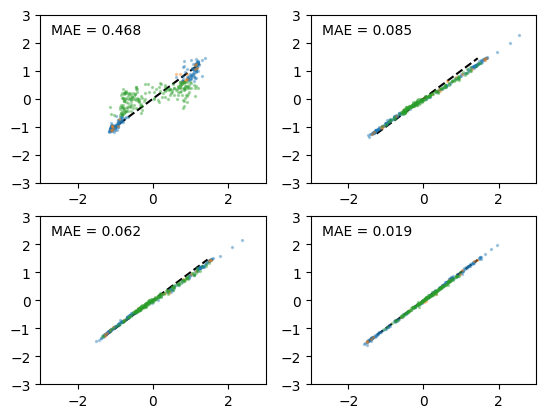

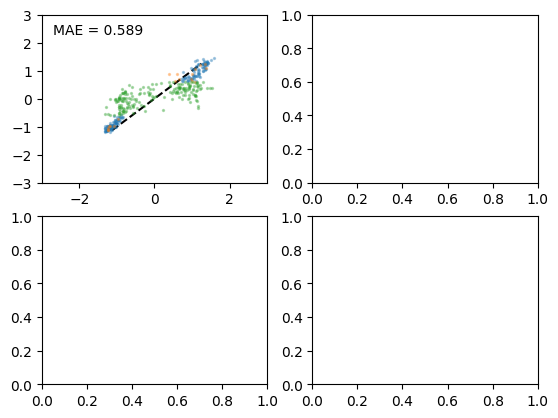

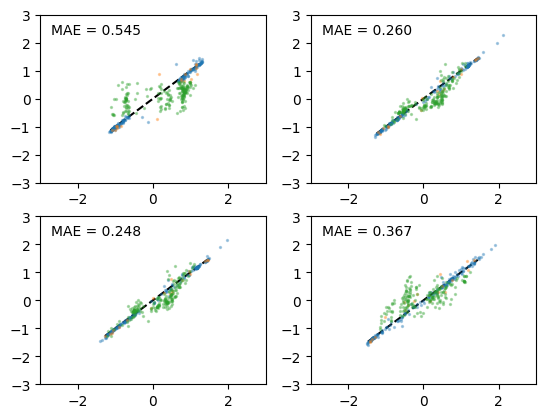

In [318]:
_ = plot_model_parity(best_model)
_ = plot_model_parity(st_model)
_ = plot_ref_parity()

In [343]:
class DynamicTaskPrioritization:
    def __init__(self, num_tasks, gamma=2, epsilon=1e-8):
        self.num_tasks = num_tasks
        self.gamma = gamma
        self.epsilon = epsilon
        self.task_losses = np.zeros(num_tasks)
        self.task_weights = np.ones(num_tasks) / num_tasks

    def update_task_losses(self, new_losses):
        """
        Update the task losses with the latest values.
        :param new_losses: List or numpy array of new loss values for each task
        """
        self.task_losses = np.array(new_losses)

    def compute_weights(self):
        """
        Compute new task weights based on the current task losses.
        """
        # Avoid division by zero
        adjusted_losses = self.task_losses + self.epsilon
        
        # Compute weights according to the formula in the paper
        weights = adjusted_losses ** self.gamma
        normalized_weights = weights / np.sum(weights)
        
        self.task_weights = normalized_weights
        return self.task_weights

    def get_torch_weights(self):
        """
        Return the current weights as a PyTorch tensor.
        """
        return torch.FloatTensor(self.task_weights)

In [400]:
input_dim = x_train.shape[1]
hidden_dim = (12, 12, 12, )
output_dim = y_train.shape[1]
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim, activation=nn.ELU())
optimizer = optim.Adam(model.parameters(), lr=1e-3)
pcgrad_mtl = wPCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5)
dtp = DynamicTaskPrioritization(output_dim, gamma=2)
task_priority = [0]

explored_values = []
frontier = []

last_best = 0
last_valid_best = 0
best_valid = np.inf
best_model = None

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 10 * n_write
for epoch in range(num_epochs):
    losses = pcgrad_mtl.train_step(x_train, y_train)
    
    dtp.update_task_losses(losses)
    new_weights = dtp.compute_weights()
    pcgrad_mtl.update_task_weights(dtp.get_torch_weights())

    m = pcgrad_mtl.model
    with torch.no_grad():
        m.eval()
        reg_loss = m.regularization_loss()
        outputs = m(x_valid)
        valid_loss = criterion(outputs[:, task_priority], y_valid[:, task_priority])
        m.train()
    
    # point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    point = np.array([valid_loss.item()])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(m)
            last_valid_best = epoch

    if reg_loss.item() < 1:
        break

    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

    if epoch - last_valid_best > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

    if (epoch+1) % n_write == 0:
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train)[:, task_priority], y_train[:, task_priority])
            valid_loss = criterion(m(x_valid)[:, task_priority], y_valid[:, task_priority])
            test_loss = criterion(m(x_test)[:, task_priority], y_test[:, task_priority])
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        m.train()

Epoch 100, MSE: 0.7334, L0R: 613.35, ValMSE: 0.7154, TestMSE: 3.2981
Epoch 200, MSE: 0.4407, L0R: 617.55, ValMSE: 0.2926, TestMSE: 1.3066
Epoch 300, MSE: 0.4138, L0R: 620.04, ValMSE: 0.2143, TestMSE: 0.9489
Epoch 400, MSE: 0.4035, L0R: 620.64, ValMSE: 0.2073, TestMSE: 1.0032
Epoch 500, MSE: 0.3958, L0R: 621.28, ValMSE: 0.2044, TestMSE: 1.0038
Epoch 600, MSE: 0.3895, L0R: 621.78, ValMSE: 0.2087, TestMSE: 1.0412
Epoch 700, MSE: 0.3837, L0R: 622.29, ValMSE: 0.1925, TestMSE: 0.9219
Epoch 800, MSE: 0.3776, L0R: 622.83, ValMSE: 0.1908, TestMSE: 0.9143
Epoch 900, MSE: 0.3786, L0R: 623.41, ValMSE: 0.1819, TestMSE: 0.8063
Epoch 1000, MSE: 0.3648, L0R: 623.99, ValMSE: 0.1892, TestMSE: 0.9602
Epoch 1100, MSE: 0.3641, L0R: 624.29, ValMSE: 0.1977, TestMSE: 1.0190
Epoch 1200, MSE: 0.3576, L0R: 624.92, ValMSE: 0.1883, TestMSE: 0.9217
Epoch 1300, MSE: 0.3558, L0R: 625.40, ValMSE: 0.1853, TestMSE: 0.8583
Epoch 1400, MSE: 0.3530, L0R: 626.01, ValMSE: 0.1787, TestMSE: 0.7816
Epoch 1500, MSE: 0.3459, L0R:

In [398]:
10*16 + 16*16 + 16*16 + 16*16 + 16*4

992

my R2 0.8996599167585373
my R2 0.9963895792607218
my R2 0.9973035408183932
my R2 0.9944239864125848
my R2 0.9589698240160942


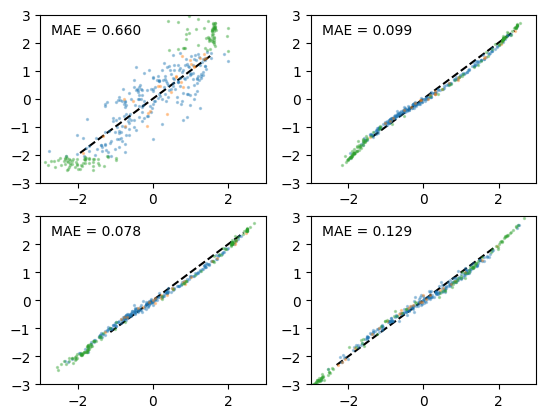

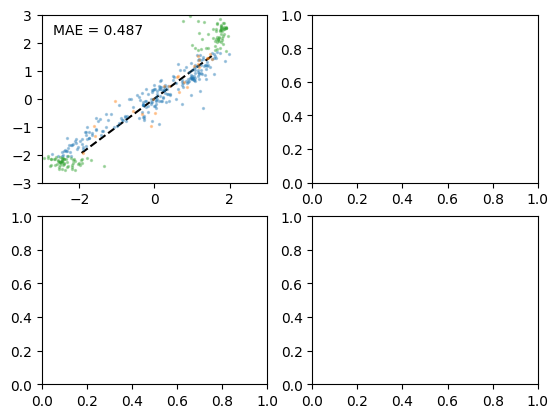

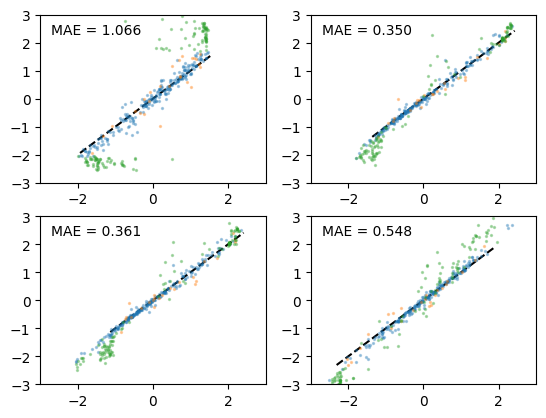

In [401]:
_ = plot_model_parity(best_model)
_ = plot_model_parity(st_model)
_ = plot_ref_parity()

In [332]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

class LWFRegression(object):
    def __init__(self, model, num_tasks, lr=1e-2, criterion=sparsenn.MultiTaskMSELoss(), lwf_lambda=1.0):
        self.model = model
        self.num_tasks = num_tasks
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.criterion = criterion
        self.lwf_lambda = lwf_lambda
        self.old_model = None
    
    def prepare_lwf(self):
        # Create a copy of the current model to serve as the "old" model
        self.old_model = copy.deepcopy(self.model)
        self.old_model.eval()
    
    def compute_lwf_loss(self, inputs, target_task):
        # Get outputs from the old model
        with torch.no_grad():
            old_outputs = self.old_model(inputs)
        
        # Get outputs from the current model
        current_outputs = self.model(inputs)
        
        lwf_loss = 0
        for task in range(self.num_tasks):
            if task != target_task:
                # Use MSE for regression tasks
                lwf_loss += self.criterion(
                    current_outputs[:, task].unsqueeze(1),
                    old_outputs[:, task].unsqueeze(1)
                )
        
        return lwf_loss
    
    def fine_tune_step(self, inputs, targets, target_task):
        self.model.train()
        outputs = self.model(inputs)

        # If 2D, we select the target task column
        target_loss = self.criterion(outputs[:, target_task].unsqueeze(1), targets[:, target_task].unsqueeze(1))
        
        # Compute the LWF loss
        lwf_loss = self.compute_lwf_loss(inputs, target_task)
        
        # Combine the losses
        total_loss = target_loss + self.lwf_lambda * lwf_loss
        
        # Compute gradients and update the model
        self.optimizer.zero_grad()
        total_loss.backward()
        self.optimizer.step()
        
        return total_loss.item(), target_loss.item(), lwf_loss.item()

In [339]:
lwf_trainer = LWFRegression(deepcopy(pcgrad_mtl.model), output_dim, lr=1e-2, lwf_lambda=1.0)
lwf_trainer.prepare_lwf()
target_task = 0

last_best = 0
last_valid_best = 0
best_valid = np.inf
best_model = None

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 10 * n_write
for epoch in range(num_epochs):
    total_loss, target_loss, lwf_loss = lwf_trainer.fine_tune_step(x_train, y_train, target_task)

    m = lwf_trainer.model
    
    # BOILERPLATE
    with torch.no_grad():
        m.eval()
        reg_loss = m.regularization_loss()
        outputs = m(x_valid)
        valid_loss = criterion(outputs[:, target_task], y_valid[:, target_task])
        m.train()
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(m)
            last_valid_best = epoch

    if reg_loss.item() < 1:
        break

    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

    if epoch - last_valid_best > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

    if (epoch+1) % n_write == 0:
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train)[:, target_task], y_train[:, target_task])
            valid_loss = criterion(m(x_valid)[:, target_task], y_valid[:, target_task])
            test_loss = criterion(m(x_test)[:, target_task], y_test[:, target_task])
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        m.train()

Epoch 100, MSE: 0.0699, L0R: 939.94, ValMSE: 0.0733, TestMSE: 0.2863
Epoch 200, MSE: 0.0417, L0R: 938.83, ValMSE: 0.0699, TestMSE: 0.2674
Epoch 300, MSE: 0.1022, L0R: 938.73, ValMSE: 0.0955, TestMSE: 0.3823
Epoch 400, MSE: 0.0761, L0R: 939.01, ValMSE: 0.0841, TestMSE: 0.3475
Epoch 500, MSE: 0.1262, L0R: 938.92, ValMSE: 0.1224, TestMSE: 0.4482
Epoch 600, MSE: 0.0435, L0R: 938.84, ValMSE: 0.0581, TestMSE: 0.3455
Epoch 700, MSE: 0.0507, L0R: 938.01, ValMSE: 0.0628, TestMSE: 0.3510
Epoch 800, MSE: 0.0385, L0R: 938.34, ValMSE: 0.0638, TestMSE: 0.3671
Epoch 900, MSE: 0.0513, L0R: 938.28, ValMSE: 0.0780, TestMSE: 0.4161
Epoch 1000, MSE: 0.0672, L0R: 938.74, ValMSE: 0.0875, TestMSE: 0.4472
Epoch 1100, MSE: 0.0291, L0R: 938.66, ValMSE: 0.0570, TestMSE: 0.3492
Epoch 1200, MSE: 0.0522, L0R: 938.96, ValMSE: 0.0599, TestMSE: 0.3965
Epoch 1300, MSE: 0.0449, L0R: 939.61, ValMSE: 0.0658, TestMSE: 0.4309
Epoch 1400, MSE: 0.0558, L0R: 939.99, ValMSE: 0.0725, TestMSE: 0.4546
Epoch 1500, MSE: 0.0341, L0R:

my R2 -1.9367733001708984
my R2 0.8880338445305824
my R2 0.8672727346420288
my R2 0.8582306355237961
my R2 -3.25567626953125


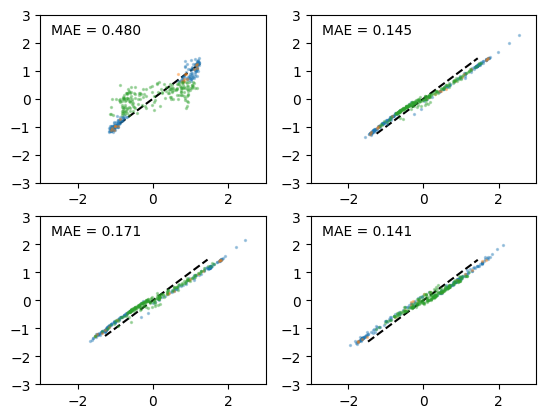

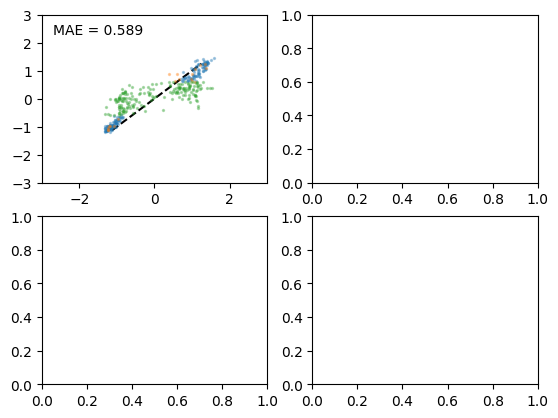

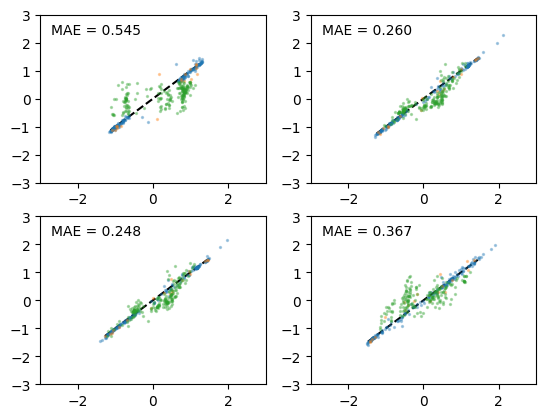

In [340]:
_ = plot_model_parity(best_model)
_ = plot_model_parity(st_model)
_ = plot_ref_parity()